In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [3]:
# 1️⃣ Check for null values
print(df.isnull().sum())

# 2️⃣ Drop rows with null values
df = df.dropna()

# 3️⃣ Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# 4️⃣ Feature Scaling (normalize numeric values)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for readability
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 5️⃣ Split data into train & test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 6️⃣ Print shapes to confirm
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
Train shape: (820, 13)
Test shape: (205, 13)


In [4]:
from sklearn.linear_model import LogisticRegression

# Create and train the model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [5]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predict on test data
y_pred_lr = log_reg.predict(X_test)

# Evaluate performance
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", round(acc_lr, 4))

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8098

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



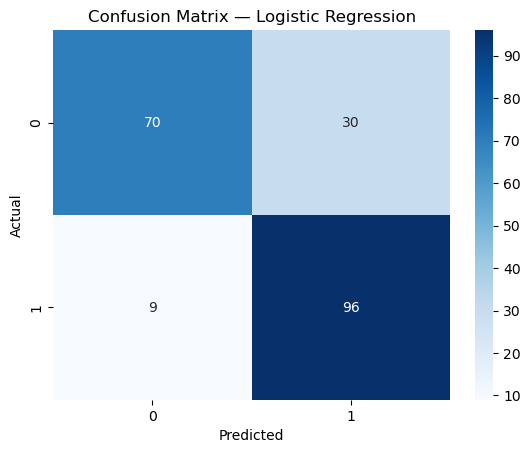


🔵 Logistic Regression — Complexity
Time Complexity:  O(n_samples × n_features × max_iter)
Calculated: 10660000
Space Complexity: O(n_features)
Calculated: 13


In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ---------------------------------------------------------
#  TIME & SPACE COMPLEXITY (Logistic Regression)
# ---------------------------------------------------------

def logistic_regression_complexity(n_samples, n_features, max_iter=1000):
    """
    Logistic Regression:
    Time:  O(n_samples × n_features × max_iter)
    Space: O(n_features)
    """
    time_complexity = n_samples * n_features * max_iter
    space_complexity = n_features

    print("\n🔵 Logistic Regression — Complexity")
    print("Time Complexity:  O(n_samples × n_features × max_iter)")
    print("Calculated:", time_complexity)
    print("Space Complexity: O(n_features)")
    print("Calculated:", space_complexity)

    return time_complexity, space_complexity

# Call the complexity function
time_lr, space_lr = logistic_regression_complexity(
    n_samples=len(X_train),
    n_features=X_train.shape[1],
    max_iter=1000
)

Random Forest Accuracy: 0.926829268292683
Confusion Matrix:
 [[ 88  12]
 [  3 102]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.92       100
           1       0.89      0.97      0.93       105

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



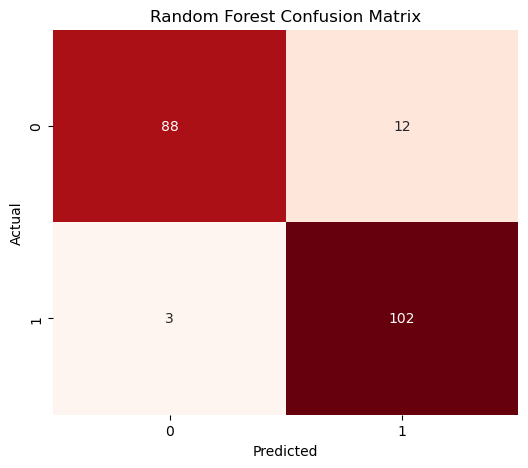


🟩 Random Forest — Complexity
Time Complexity:  O(n_trees × n_samples × n_features × log n)
Calculated: 9594000
Space Complexity: O(n_trees × n_features × max_depth)
Calculated: 6500


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Limit tree depth to reduce overfitting
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
accuracy_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Confusion Matrix:\n", cm_rf)
print("Classification Report:\n", report_rf)

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# ---------------------------------------------------------
#  TIME & SPACE COMPLEXITY (Random Forest)
# ---------------------------------------------------------

import math

def random_forest_complexity(n_samples, n_features, n_trees=100, max_depth=5):
    """
    Random Forest:
    Time:  O(n_trees × n_samples × n_features × log n)
    Space: O(n_trees × n_features × max_depth)
    """
    time_complexity = n_trees * n_samples * n_features * int(math.log2(n_samples))
    space_complexity = n_trees * n_features * max_depth

    print("\n🟩 Random Forest — Complexity")
    print("Time Complexity:  O(n_trees × n_samples × n_features × log n)")
    print("Calculated:", time_complexity)
    print("Space Complexity: O(n_trees × n_features × max_depth)")
    print("Calculated:", space_complexity)

    return time_complexity, space_complexity

# Call the complexity function
time_rf, space_rf = random_forest_complexity(
    n_samples=len(X_train),
    n_features=X_train.shape[1],
    n_trees=100,
    max_depth=5
)

Decision Tree Accuracy: 0.8731707317073171
Confusion Matrix:
 [[85 15]
 [11 94]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.85      0.87       100
           1       0.86      0.90      0.88       105

    accuracy                           0.87       205
   macro avg       0.87      0.87      0.87       205
weighted avg       0.87      0.87      0.87       205



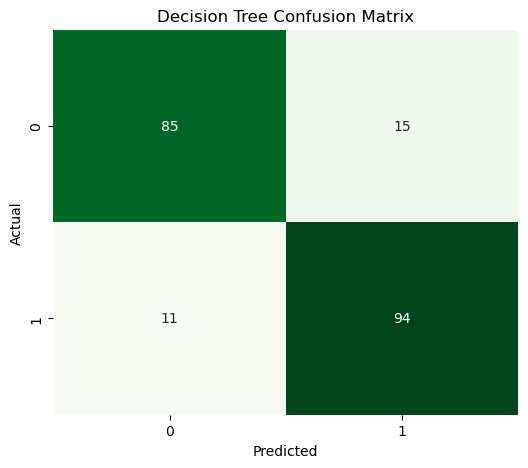


🟦 Decision Tree — Complexity
Time Complexity:  O(n_samples × n_features × log n)
Calculated: 95940
Space Complexity: O(n_features × max_depth)
Calculated: 65


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate
accuracy_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)
print("Confusion Matrix:\n", cm_dt)
print("Classification Report:\n", report_dt)

# Visualize confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# ---------------------------------------------------------
#  TIME & SPACE COMPLEXITY (Decision Tree)
# ---------------------------------------------------------

import math

def decision_tree_complexity(n_samples, n_features, max_depth=5):
    """
    Decision Tree:
    Time:  O(n_samples × n_features × log n)
    Space: O(n_features × max_depth)
    """
    time_complexity = n_samples * n_features * int(math.log2(n_samples))
    space_complexity = n_features * max_depth

    print("\n🟦 Decision Tree — Complexity")
    print("Time Complexity:  O(n_samples × n_features × log n)")
    print("Calculated:", time_complexity)
    print("Space Complexity: O(n_features × max_depth)")
    print("Calculated:", space_complexity)

    return time_complexity, space_complexity

# Call the complexity function
time_dt, space_dt = decision_tree_complexity(
    n_samples=len(X_train),
    n_features=X_train.shape[1],
    max_depth=5
)

📊 Model Accuracy Comparison:

                 Model  Accuracy
0  Logistic Regression  0.809756
1        Decision Tree  0.873171
2        Random Forest  0.926829


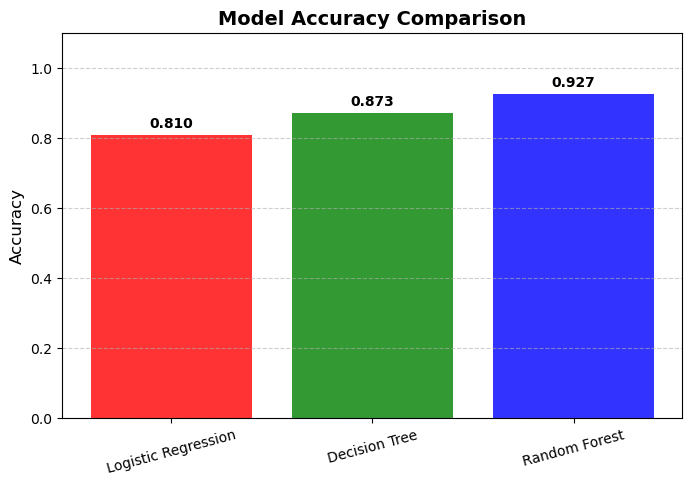

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# ✅ Model accuracies (replace these with your actual accuracy variables)
accuracy_lr = acc_lr                # Logistic Regression
accuracy_dt = accuracy_dt           # Decision Tree
accuracy_rf = accuracy_rf           # Random Forest

# 🧾 Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_dt, accuracy_rf]
})

print("📊 Model Accuracy Comparison:\n")
print(comparison_df)

# 🎨 Plot the bar chart
colors = ['red', 'green', 'blue']

plt.figure(figsize=(8,5))
bars = plt.bar(comparison_df['Model'], comparison_df['Accuracy'], color=colors, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.3f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Model Accuracy Comparison", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=15)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


⏳ Training Time Complexity Comparison:

                 Model  Time Complexity
0  Logistic Regression         10660000
1        Decision Tree            95940
2        Random Forest          9594000


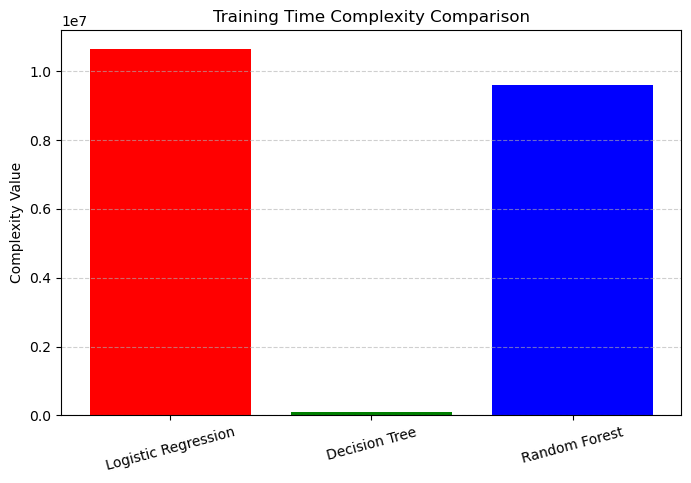

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

training_time_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Time Complexity': [time_lr, time_dt, time_rf]
})

print("\n⏳ Training Time Complexity Comparison:\n")
print(training_time_df)

plt.figure(figsize=(8,5))
plt.bar(training_time_df['Model'], training_time_df['Time Complexity'], color=['red','green','blue'])
plt.xticks(rotation=15)
plt.title("Training Time Complexity Comparison")
plt.ylabel("Complexity Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


💾 Space Complexity Comparison:

                 Model  Space Complexity
0  Logistic Regression                13
1        Decision Tree                65
2        Random Forest              6500


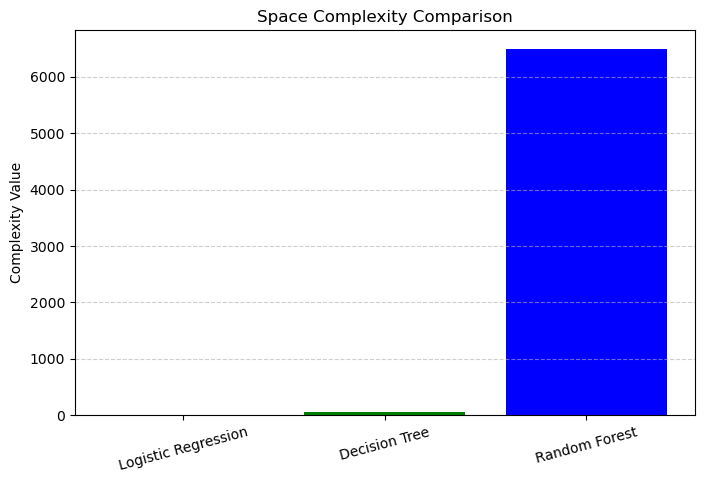

In [11]:
space_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Space Complexity': [space_lr, space_dt, space_rf]
})

print("\n💾 Space Complexity Comparison:\n")
print(space_df)

plt.figure(figsize=(8,5))
plt.bar(space_df['Model'], space_df['Space Complexity'], color=['red','green','blue'])
plt.xticks(rotation=15)
plt.title("Space Complexity Comparison")
plt.ylabel("Complexity Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()